$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.9

## 理论

上述所有拉丁超立方设计（LHD）均采用式 (4.21) 中的中心化数值，该方式可为一维投影构造极小极大设计。若将切比雪夫设计融合至极大极小拉丁超立方设计（MmLHD）中，可先构造一组极大极小拉丁超立方设计，再借助式 (2.5) 对数值做变换，变换形式为 $D_{ij} \leftarrow \{1+\cos(\pi D_{ij})\}/2$，其中矩阵 $D$ 代表极大极小拉丁超立方设计。图 4.9 展示了包含 20 次试验的原始极大极小拉丁超立方设计，以及经过切比雪夫变换后的极大极小拉丁超立方设计。不难发现，切比雪夫变换会将样本点向区间边界推移。该方法与式 (4.18) 中的 TRD 准则存在紧密关联。考虑一维情形，即维度 $p=1$，易证：

$$
\begin{align*}
\lim_{\alpha \to 0}\left\{\sum_{i=1}^{n}\sum_{j\neq i}\frac{1}{|x_i-x_j|^{2\alpha}}\right\}^{1/\alpha}
&\propto\lim_{\alpha \to 0}\frac{1}{\alpha}\log\left(\sum_{i=1}^{n}\sum_{j\neq i}e^{-2\alpha\log|x_{i}-x_{j}|}\right)\\
&\propto\lim_{\alpha \to 0}\log\left(\sum_{i=1}^{n}\sum_{j\neq i}-2\log|x_i-x_j|\right)\quad(\text{泰勒展开})\\
&\propto-2\sum_{i=1}^{n}\sum_{j\neq i}\log|x_i-x_j|\quad(\text{泰勒展开})
\end{align*}
$$

最终结果被称作对数势能。当样本量 $n$ 趋于无穷时，使对数势能准则最小化的设计服从反正弦分布，其概率密度函数为：

$$
f(x)=\frac{1}{\pi x\sqrt{1-x}}
$$

$n$ 点切比雪夫设计能够对该密度实现最优分位数逼近。正如前文图 3.3 所示，切比雪夫设计在拟合光滑函数时表现优异，但拟合粗糙函数的效果较差。由此可见，经过切比雪夫变换得到的设计，在相关参数设定出现偏差时不具备稳健性。

## 实践

创建画布宽 20 英寸、高 10 英寸，将画布分为 1x2。令 p=2、n=20，设置种子为 1。导入 SFDesign 包，调用 maximinLHD() 函数生成 n 个点，p 维的初始极大极小拉丁超立方设计，设计点令其为 D。绘制设计点散点图，其中点型为 16，大小为 4，无边框，颜色为 blue，x、y 轴的范围均为 c(0,1)，x 轴的标签为 expression(x[1])，y 轴的标签为 expression(x[2])，大小为 2，标题为 “极大极小拉丁超立方设计”，大小为 3，纵横比为 1。叠加网格，将 $[0,1]^{2}$ 空间划分 20x20 的网格。

依据公式

$$
D_{ij} \leftarrow \{1+\cos(\pi D_{ij})\}/2
$$

将均匀设计 D 转化成切比雪夫设计。绘制设计点散点图，其中点型为 16，大小为 4，无边框，颜色为 blue，x、y 轴的范围均为 c(0,1)，x 轴的标签为 expression(x[1])，y 轴的标签为 expression(x[2])，大小为 2，标题为 “切比雪夫型极大极小拉丁超立方设计”，大小为 3，纵横比为 1。给 D 的每一列排序，得到 d1、d2。计算相邻两个点的中点，得到 l1、l2。使用 l1、l2 绘制叠加网格，将 $[0,1]^{2}$ 空间划分 20x20 的网格。将画布还原回 1x1。

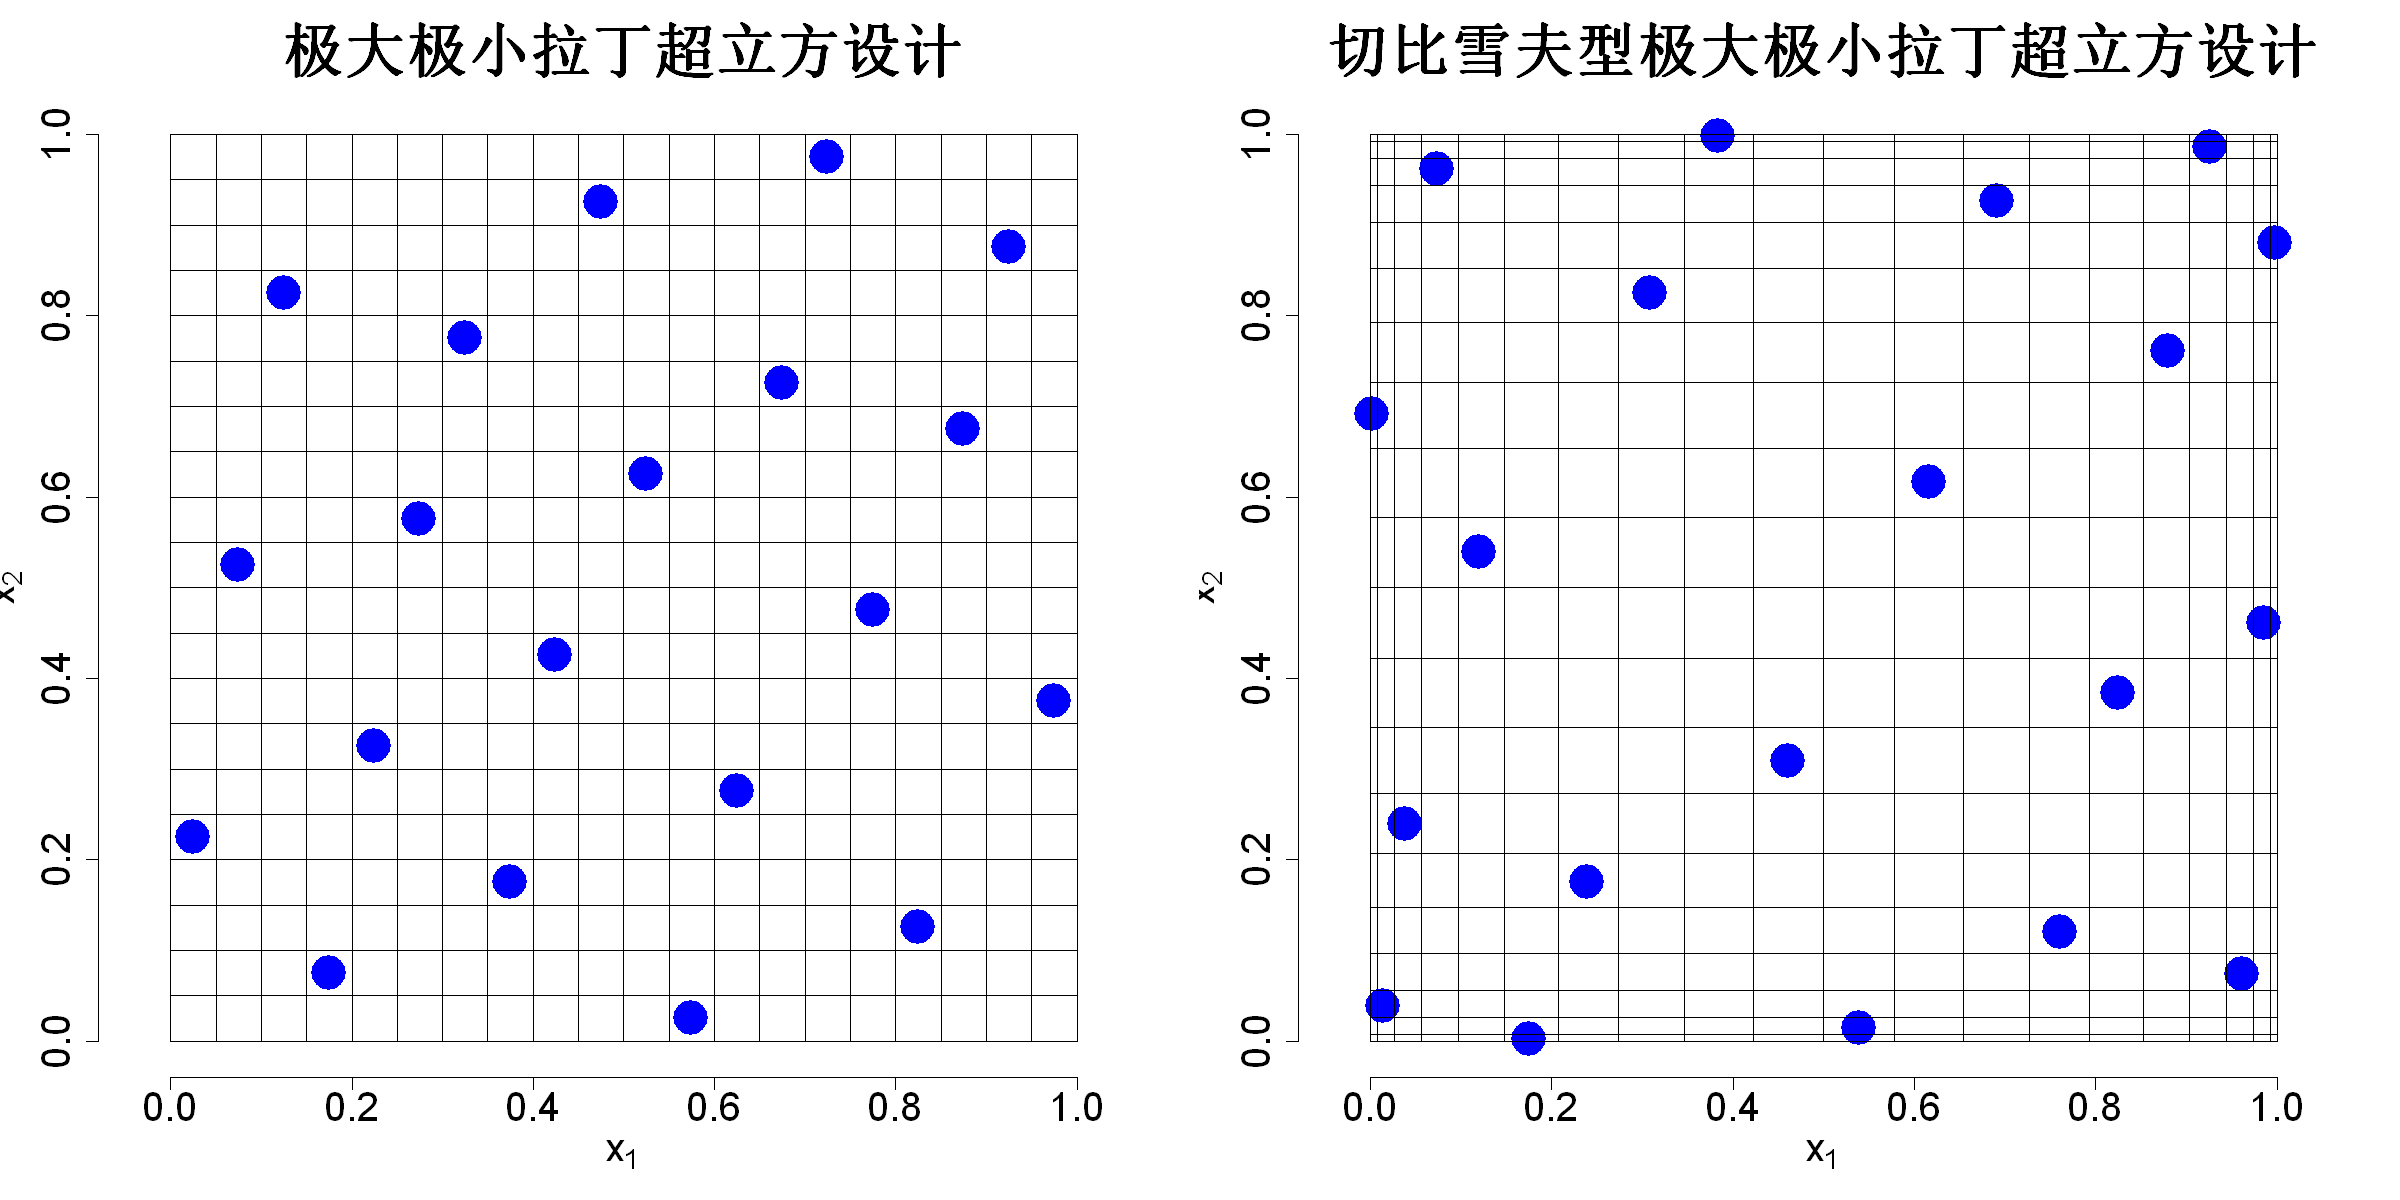

In [2]:
if(!dir.exists("data"))dir.create("data")
if((!file.exists("data/4.9-D.csv"))||(!file.exists("data/4.9-para.csv"))){
  p=2;n=20
  set.seed(1)
  library(SFDesign)
  D1=maximinLHD(n,p)$design # 20x2
  D2=(1+cos(pi*D1))/2 # 20x2
  write.csv(data.frame(D1=D1,D2=D2),"data/4.9-D.csv",row.names=FALSE)
  write.csv(data.frame(n=n),"data/4.9-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.9-D.csv")
D1=as.matrix(df_D[,paste0("D1.",1:2)])
D2=as.matrix(df_D[,paste0("D2.",1:2)])
para=read.csv("data/4.9-para.csv")
n=para$n

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(D1,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),main="极大极小拉丁超立方设计",cex.lab=2,cex.axis=2,cex.main=3,asp=1)
for(i in 1:(n+1)){
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
plot(D2,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="切比雪夫型极大极小拉丁超立方设计",cex.main=3,asp=1)
d1=sort(D2[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D2[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1)){
segments(l1[i],0,l1[i],1)
segments(0,l2[i],1,l2[i])
}

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$